# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [7]:
df = pd.read_csv("cleaned_aviation_data.csv") 

df.head()
df.info()

c:\Users\BEST\anaconda3\envs\learn-env\lib\site-packages\IPython\core\interactiveshell.py:3145: DtypeWarning: Columns (0) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17104 entries, 0 to 17103
Data columns (total 35 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                17104 non-null  object 
 1   Investigation.Type      17104 non-null  object 
 2   Accident.Number         17104 non-null  object 
 3   Event.Date              17104 non-null  object 
 4   Location                17100 non-null  object 
 5   Country                 17103 non-null  object 
 6   Latitude                15813 non-null  object 
 7   Longitude               15810 non-null  object 
 8   Airport.Code            11528 non-null  object 
 9   Airport.Name            11585 non-null  object 
 10  Injury.Severity         17104 non-null  object 
 11  Aircraft.damage         17104 non-null  object 
 12  Aircraft.Category       17104 non-null  object 
 13  Registration.Number     16974 non-null  object 
 14  Make                    17104 non-null

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [8]:
# Aircraft size groups
df['Aircraft.Size'] = np.where( 
    df['Estimated.Passengers'] < 20, 
    'Small', 
    'Large' ) 
small = df[df["Aircraft.Size"] == "Small"]
large = df[df["Aircraft.Size"] == "Large"]

print(small.shape)
print(large.shape)

(16246, 36)
(858, 36)


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [9]:
# Small aircraft
small_make = (
    small.groupby("Make")
    .agg(
        Mean_Injury=("Fatal.Serious.Rate","mean"),
        Mean_Destroyed=("Destroyed","mean"),
        Samples=("Make","count")
    )
)

small_make = small_make[small_make["Samples"]>=50]

small_best = (
    small_make
    .sort_values("Mean_Injury")
    .head(15)
)

small_best

,Mean_Injury,Mean_Destroyed,Samples
Make,,,
BOEING,0.140936,0.080292,274
AVIAT AIRCRAFT INC,0.164474,0.039474,76
MAULE,0.164806,0.041860,215
GRUMMAN ACFT ENG COR-SCHWEIZER,0.206897,0.017241,58
AYRES,0.215686,0.117647,51
STINSON,0.216408,0.023256,129
AVIAT,0.221429,0.100000,70
BELLANCA,0.222603,0.050228,219
DIAMOND AIRCRAFT IND INC,0.222973,0.054054,74


In [10]:
# Large Aircraft
large_make = (
    large.groupby("Make")
    .agg(
        Mean_Injury=("Fatal.Serious.Rate","mean"),
        Mean_Destroyed=("Destroyed","mean"),
        Samples=("Make","count")
    )
)

large_make = large_make[large_make["Samples"]>=50]

large_best = (
    large_make
    .sort_values("Mean_Injury")
    .head(15)
)

large_best

,Mean_Injury,Mean_Destroyed,Samples
Make,,,
MCDONNELL DOUGLAS,0.007827,0.075472,53
BOEING,0.056667,0.049270,548
EMBRAER,0.065274,0.051282,78
AIRBUS,0.086249,0.076271,118


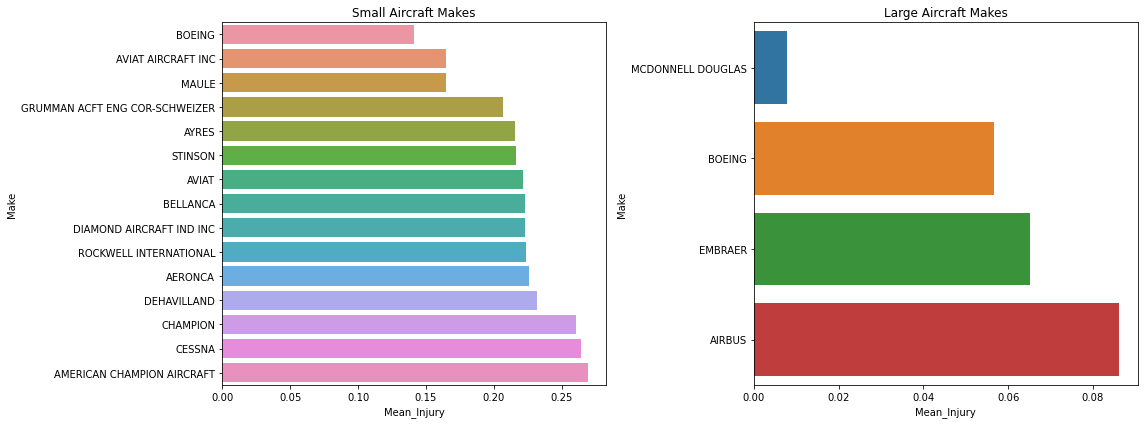

In [11]:
# Side by side comparison
fig, ax = plt.subplots(1,2,figsize=(16,6))

sns.barplot(
    data=small_best,
    x="Mean_Injury",
    y=small_best.index,
    ax=ax[0]
)

ax[0].set_title("Small Aircraft Makes")

sns.barplot(
    data=large_best,
    x="Mean_Injury",
    y=large_best.index,
    ax=ax[1]
)

ax[1].set_title("Large Aircraft Makes")

plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

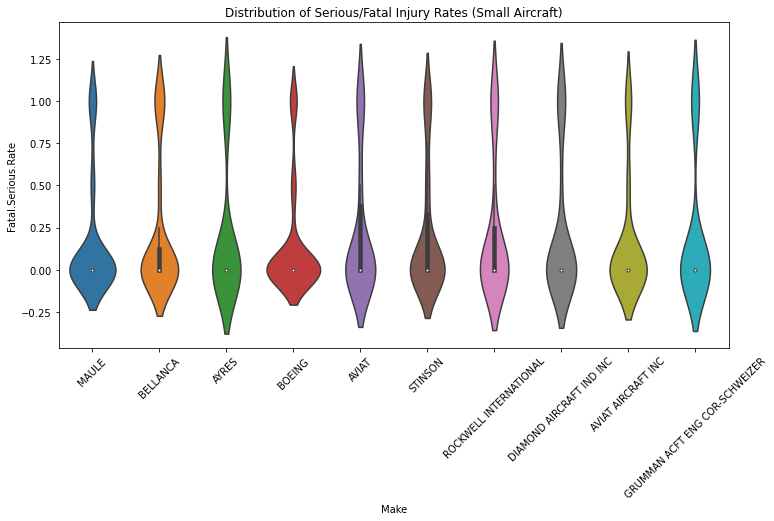

In [12]:
top10_small = small_best.head(10).index

plt.figure(figsize=(12,6))

sns.violinplot(
    data=small[small["Make"].isin(top10_small)],
    x="Make",
    y="Fatal.Serious.Rate"
)

plt.xticks(rotation=45)
plt.title("Distribution of Serious/Fatal Injury Rates (Small Aircraft)")
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

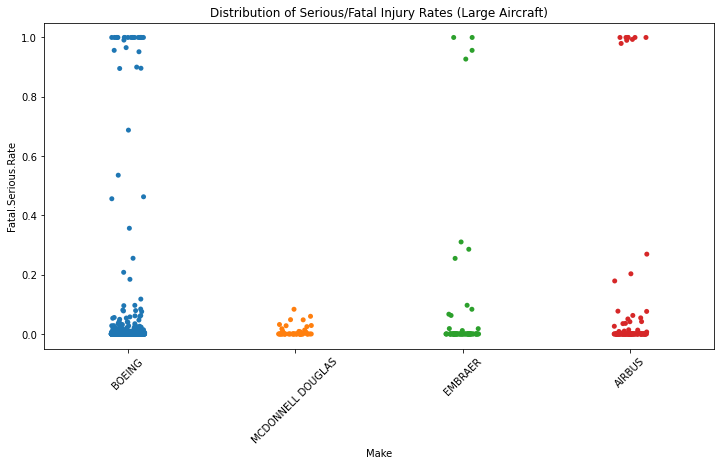

In [13]:
top10_large = large_best.head(10).index

plt.figure(figsize=(12,6))

sns.stripplot(
    data=large[large["Make"].isin(top10_large)],
    x="Make",
    y="Fatal.Serious.Rate",
    jitter=True
)

plt.xticks(rotation=45)
plt.title("Distribution of Serious/Fatal Injury Rates (Large Aircraft)")
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [14]:
# Small aircrafts
small_destroyed = (
    small_make
    .sort_values("Mean_Destroyed")
    .head(15)
)

small_destroyed

,Mean_Injury,Mean_Destroyed,Samples
Make,,,
LUSCOMBE,0.280142,0.014184,141
GRUMMAN ACFT ENG COR-SCHWEIZER,0.206897,0.017241,58
STINSON,0.216408,0.023256,129
TAYLORCRAFT,0.306452,0.032258,93
AERONCA,0.225833,0.035000,200
AMERICAN CHAMPION AIRCRAFT,0.269231,0.038462,52
ERCOUPE,0.320513,0.038462,52
AVIAT AIRCRAFT INC,0.164474,0.039474,76
MAULE,0.164806,0.041860,215


In [15]:
# Large aircraft
large_destroyed = (
    large_make
    .sort_values("Mean_Destroyed")
    .head(15)
)

large_destroyed

,Mean_Injury,Mean_Destroyed,Samples
Make,,,
BOEING,0.056667,0.049270,548
EMBRAER,0.065274,0.051282,78
MCDONNELL DOUGLAS,0.007827,0.075472,53
AIRBUS,0.086249,0.076271,118


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

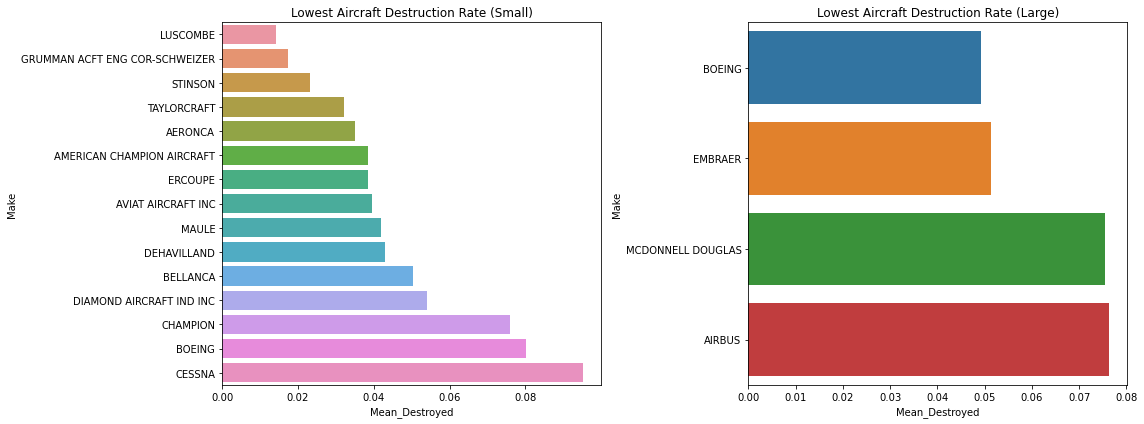

In [16]:
fig, ax = plt.subplots(1,2,figsize=(16,6))

sns.barplot(
    data=small_destroyed,
    x="Mean_Destroyed",
    y=small_destroyed.index,
    ax=ax[0]
)

ax[0].set_title("Lowest Aircraft Destruction Rate (Small)")

sns.barplot(
    data=large_destroyed,
    x="Mean_Destroyed",
    y=large_destroyed.index,
    ax=ax[1]
)

ax[1].set_title("Lowest Aircraft Destruction Rate (Large)")

plt.tight_layout()
plt.show()

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

In [17]:
plane_stats = (
    df.groupby("Plane.Type")
    .agg(
        Mean_Injury=("Fatal.Serious.Rate","mean"),
        Samples=("Plane.Type","count")
    )
)

plane_stats = plane_stats[
    plane_stats["Samples"]>=10
]

**Larger planes**

In [18]:
large_planes = (
    large.groupby("Plane.Type")
    .agg(
        Mean_Injury=("Fatal.Serious.Rate","mean"),
        Samples=("Plane.Type","count")
    )
)

large_planes = large_planes[
    large_planes["Samples"]>=10
]

large_planes = large_planes.sort_values("Mean_Injury").head(15)

large_planes

,Mean_Injury,Samples
Plane.Type,,
BOEING 777,0.000821,33
BOEING 757,0.001473,18
BOEING 787,0.003058,11
BOEING 737-7H4,0.003242,12
BOMBARDIER INC CL-600-2B19,0.004136,15
EMBRAER EMB145,0.008798,11
EMBRAER EMB-145LR,0.010000,15
BOEING 747,0.023161,11
BOEING 767,0.046963,31


**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

In [19]:
small_planes = (
    small.groupby("Plane.Type")
    .agg(
        Mean_Injury=("Fatal.Serious.Rate","mean"),
        Samples=("Plane.Type","count")
    )
)

small_planes = small_planes[
    small_planes["Samples"]>=10
]

small_planes = small_planes.sort_values("Mean_Injury").head(10)

small_planes

,Mean_Injury,Samples
Plane.Type,,
CESSNA 172SP,0.000000,12
DIAMOND AIRCRAFT IND INC DA 20 C1,0.000000,11
MAULE M-5-210C,0.000000,11
CESSNA 180J,0.035714,28
CESSNA A185E,0.038889,18
PIPER PA-20,0.040000,25
AIR TRACTOR AT 602,0.041667,12
BEECH B19,0.041667,16
CESSNA 560XL,0.047619,21


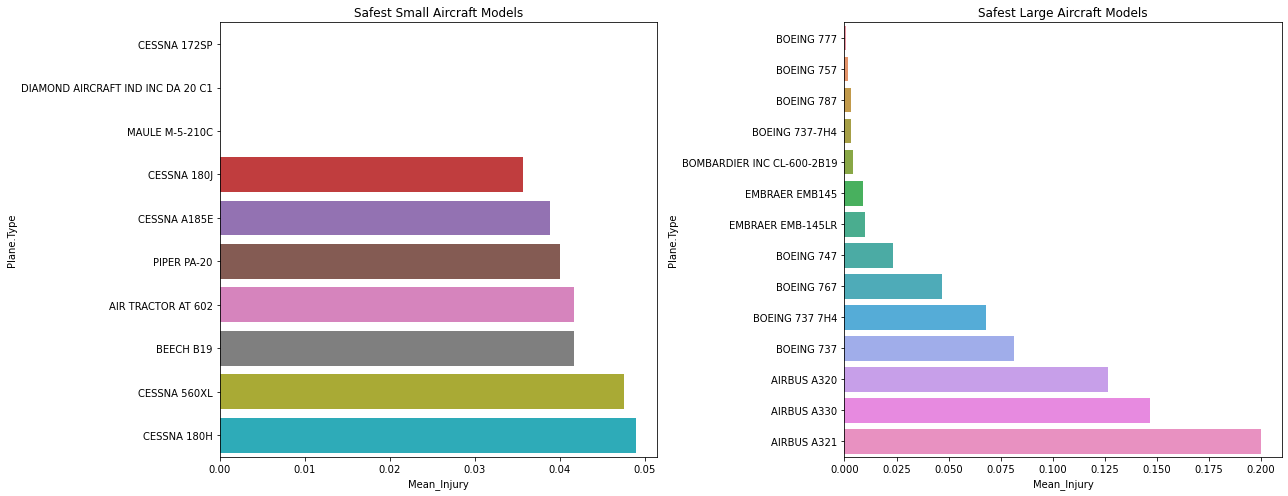

In [20]:
# Plot Plane Types
fig, ax = plt.subplots(1,2,figsize=(18,7))

sns.barplot(
    data=small_planes,
    x="Mean_Injury",
    y=small_planes.index,
    ax=ax[0]
)

ax[0].set_title("Safest Small Aircraft Models")

sns.barplot(
    data=large_planes,
    x="Mean_Injury",
    y=large_planes.index,
    ax=ax[1]
)

ax[1].set_title("Safest Large Aircraft Models")

plt.tight_layout()
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

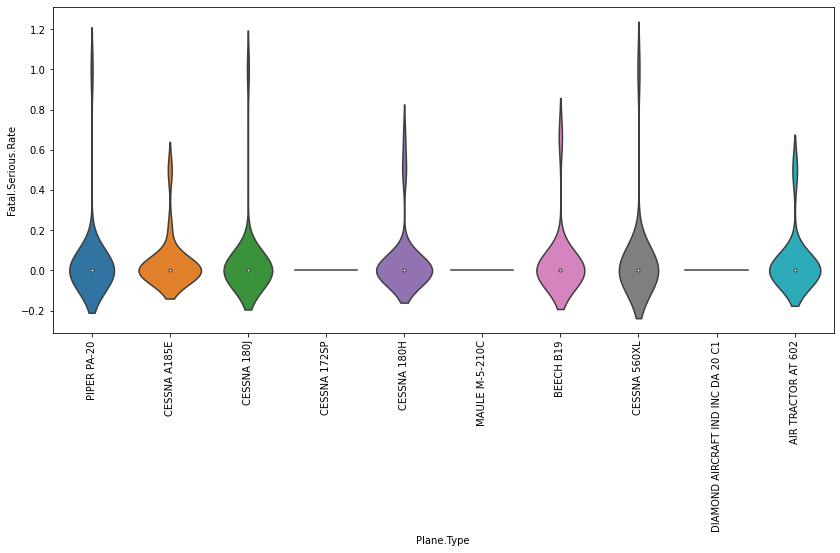

In [21]:
plt.figure(figsize=(14,6))

sns.violinplot(
    data=small[
        small["Plane.Type"].isin(small_planes.index)
    ],
    x="Plane.Type",
    y="Fatal.Serious.Rate"
)

plt.xticks(rotation=90)
plt.show()

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

In [22]:
# Weather condition
weather_summary = (
    df.groupby("Weather.Condition")
    .agg(
        Injury=("Fatal.Serious.Rate","mean"),
        Destroyed=("Destroyed","mean"),
        Count=("Weather.Condition","count")
    )
)

weather_summary

,Injury,Destroyed,Count
Weather.Condition,,,
IMC,0.631233,0.354260,892
UNK,0.219167,0.285714,56
Unk,0.498620,0.309524,168
Unknown,0.422044,0.233871,1736
VMC,0.233418,0.071078,14252


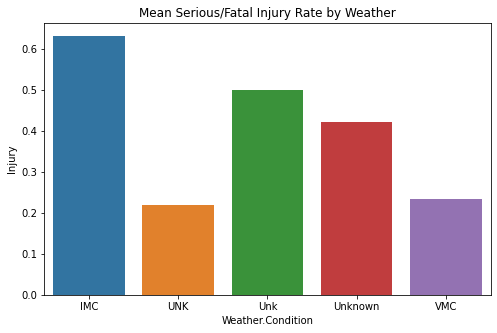

In [24]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=weather_summary.reset_index(),
    x="Weather.Condition",
    y="Injury"
)

plt.title("Mean Serious/Fatal Injury Rate by Weather")
plt.show()

In [27]:
# Purpose of Flight
purpose_summary = (
    df.groupby("Purpose.of.flight")
    .agg(
        Mean_Injury_Rate=("Fatal.Serious.Rate", "mean"),
        Destruction_Rate=("Destroyed", "mean"),
        Average_Passengers=("Estimated.Passengers", "mean"),
        Accident_Count=("Purpose.of.flight", "count")
    )
    .sort_values(by="Mean_Injury_Rate")
)

purpose_summary

,Mean_Injury_Rate,Destruction_Rate,Average_Passengers,Accident_Count
Purpose.of.flight,,,,
PUBS,0.000000,0.000000,1.333333,3
AIR DROP,0.000000,0.000000,1.500000,2
AIR RACE/SHOW,0.000000,0.000000,1.500000,2
PUBLIC AIRCRAFT - FEDERAL,0.154762,0.035714,2.035714,28
INSTRUCTIONAL,0.169415,0.041425,1.722867,2414
PUBLIC AIRCRAFT - STATE,0.190476,0.000000,1.619048,21
FLIGHT TEST,0.279279,0.108108,4.067568,74
PERSONAL,0.279893,0.093623,1.853168,9848
POSITIONING,0.288319,0.124060,1.511278,266


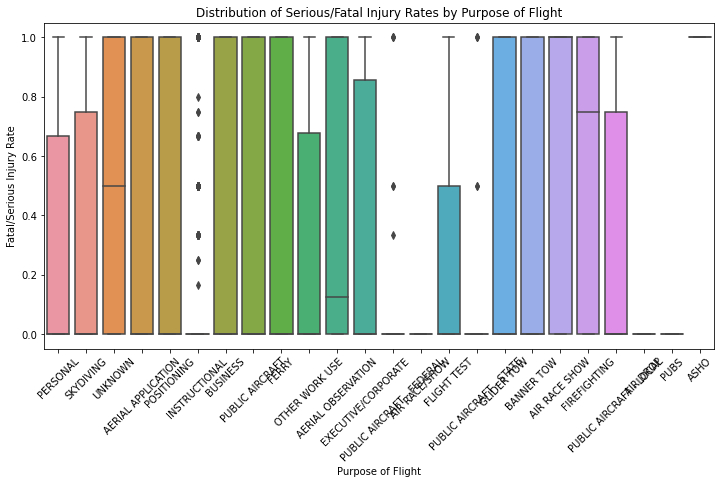

In [28]:
# plot
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Purpose.of.flight",
    y="Fatal.Serious.Rate"
)

plt.xticks(rotation=45)
plt.title("Distribution of Serious/Fatal Injury Rates by Purpose of Flight")
plt.xlabel("Purpose of Flight")
plt.ylabel("Fatal/Serious Injury Rate")

plt.show()